# ЛАБОРАТОРНАЯ РАБОТА № 7

**Тема**: Написание простейшей нейросети с нуля для датасета из 1 лабораторной.

**Постановка**: Написать простейшую нейронную сеть и пайплайн обучения для классификации с нуля.

**Цель**: Обосновать выбор функции активации и функции потерь.
Попробовать несколько различных архитектур/конфигураций, провести обучение и сравнить результаты.

## Загрузка данных

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings('ignore')

### Установим красивые дефолтные настройки

import matplotlib as mlp

mlp.rcParams['lines.linewidth'] = 5
mlp.rcParams['xtick.major.size'] = 20
mlp.rcParams['xtick.major.width'] = 5
mlp.rcParams['xtick.labelsize'] = 20
mlp.rcParams['xtick.color'] = '#FF5533'

mlp.rcParams['ytick.major.size'] = 20
mlp.rcParams['ytick.major.width'] = 5
mlp.rcParams['ytick.labelsize'] = 20
mlp.rcParams['ytick.color'] = '#FF5533'

mlp.rcParams['axes.labelsize'] = 20
mlp.rcParams['axes.titlesize'] = 20
mlp.rcParams['axes.titlecolor'] = '#00B050'
mlp.rcParams['axes.labelcolor'] = '#00B050'

import pandas as pd

### Прочитаем табличку для 1 лабы
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/7 лаба/data_saved.csv')


data.head(20)

,total_area,rooms,ceiling_height,floors_total,floor,studio,airports_distance,centers_distance,balcony_1.0,balcony_2.0,balcony_3.0,balcony_4.0,balcony_5.0,park_category_no_park,park_category_very_close,park_category_walking_distance,ponds_category_no_park,ponds_category_very_close,ponds_category_walking_distance,log_price
0,40.4,1,2.65,11.0,1,False,12817.0,18603.0,False,True,False,False,False,True,False,False,True,False,False,15.024471
1,56.0,2,2.65,5.0,4,False,21741.0,13933.0,False,False,False,False,False,False,True,False,False,False,True,15.463400
2,30.4,1,2.65,12.0,5,False,26726.0,13100.0,True,False,False,False,False,True,False,False,True,False,False,14.876767
3,37.3,1,2.65,26.0,6,False,52996.0,19143.0,True,False,False,False,False,True,False,False,True,False,False,15.123844
4,61.0,3,2.50,9.0,7,False,50898.0,15008.0,False,True,False,False,False,True,False,False,True,False,False,15.501910
5,39.6,1,2.67,12.0,3,False,38357.0,13878.0,False,False,False,False,False,False,False,True,False,False,True,15.434899
6,44.0,2,2.65,5.0,4,False,48252.0,51677.0,True,False,False,False,False,True,False,False,True,False,False,15.009433
7,54.0,2,2.65,5.0,5,False,26726.0,13100.0,False,False,False,False,False,True,False,False,True,False,False,15.173920
8,42.8,2,2.56,5.0,5,False,37868.0,33058.0,True,False,False,False,False,False,False,True,False,False,True,15.082458
9,36.0,1,2.65,6.0,1,False,20782.0,30759.0,False,False,False,False,False,True,False,False,False,True,False,15.297115


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
data.dtypes

,0
total_area,float64
rooms,int64
ceiling_height,float64
floors_total,float64
floor,int64
studio,bool
airports_distance,float64
centers_distance,float64
balcony_1.0,bool
balcony_2.0,bool


## Реализация простейшей нейросети

In [ ]:
### фичи и таргет
X = data.drop('log_price', axis=1)
y = data['log_price']

1. Разделим на тест и трени данные
2. Стандартизируем все
3. Конвертируем дааные в тензоры для признаков и для целевой переменной.

In [ ]:
import torch

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

print(f"Data shapes: X_train {X_train_tensor.shape}, y_train {y_train_tensor.shape}")

Data shapes: X_train torch.Size([14830, 19]), y_train torch.Size([14830, 1])


Сначала реализуем линейный слой, ReLu функцию активации, также расчет лосса и создадим оптимизатор SGD

In [ ]:
### Компоненты нейросети
class LinearLayer:
    def __init__(self, input_size, output_size):
        self.weights = torch.randn(input_size, output_size) * 0.1
        self.bias = torch.zeros(1, output_size)
        self.weights.requires_grad_(True)
        self.bias.requires_grad_(True)

    def forward(self, x):
        self.input = x
        return x @ self.weights + self.bias

class ReLU:
    def forward(self, x):
        self.output = torch.maximum(x, torch.tensor(0.0))
        return self.output

    def backward(self, grad_output):
        return grad_output * (self.output > 0).float()

class MSELoss:
    def forward(self, y_pred, y_true):
        return torch.mean((y_pred - y_true) ** 2)

    def backward(self, y_pred, y_true):
        return 2 * (y_pred - y_true) / y_pred.shape[0]

class SGD:
    def __init__(self, parameters, lr=0.01):
        self.parameters = parameters
        self.lr = lr

    def step(self):
        for param in self.parameters:
            param.data -= self.lr * param.grad

    def zero_grad(self):
        for param in self.parameters:
            param.grad = None

Теперь на очереди функция для обучения модели. В ней сперва форвард для предикат, затием лосс и backward для градиентов расчета, ну и обновление весов затем. Повторяем по эпохам.

In [ ]:
def train_model(model, X, y, epochs=1000, lr=0.01):
    optimizer = SGD(model.parameters(), lr=lr)
    criterion = MSELoss()
    losses = []

    for epoch in range(epochs):
        # Forward pass
        output = model.forward(X)
        loss = criterion.forward(output, y)

        # Backward pass
        grad_output = criterion.backward(output, y)
        for layer in reversed(model.layers):
            if isinstance(layer, LinearLayer):
                layer.weights.grad = layer.input.t() @ grad_output
                layer.bias.grad = grad_output.sum(dim=0, keepdim=True)
                grad_output = grad_output @ layer.weights.t()
            elif isinstance(layer, ReLU):
                grad_output = layer.backward(grad_output)

        # Обновляем веса
        optimizer.step()
        optimizer.zero_grad()

        if epoch % 100 == 0:
            losses.append(loss.item())
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    return losses

Накодю такие базовые три архитектуры нейросетей на 1000 эпох, почему нет.

In [ ]:
### Создание и обучение моделей
class NeuralNetwork:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def parameters(self):
        params = []
        for layer in self.layers:
            if hasattr(layer, 'weights'):
                params.extend([layer.weights, layer.bias])
        return params

input_size = X_train_tensor.shape[1]

### Модель 1: простая
model1 = NeuralNetwork([
    LinearLayer(input_size, 64),
    ReLU(),
    LinearLayer(64, 1)
])

### Модель 2: глубокая
model2 = NeuralNetwork([
    LinearLayer(input_size, 128),
    ReLU(),
    LinearLayer(128, 64),
    ReLU(),
    LinearLayer(64, 1)
])

### Модель 3: широкая
model3 = NeuralNetwork([
    LinearLayer(input_size, 256),
    ReLU(),
    LinearLayer(256, 1)
])

print("Training Model 1...")
losses1 = train_model(model1, X_train_tensor, y_train_tensor, epochs=10000, lr=0.1)

print("\nTraining Model 2...")
losses2 = train_model(model2, X_train_tensor, y_train_tensor, epochs=10000, lr=0.1)

print("\nTraining Model 3...")
losses3 = train_model(model3, X_train_tensor, y_train_tensor, epochs=10000, lr=0.1)

Training Model 1...
Epoch 0, Loss: 230.8714
Epoch 100, Loss: 0.1117
Epoch 200, Loss: 0.0850
Epoch 300, Loss: 0.0778
Epoch 400, Loss: 0.0747
Epoch 500, Loss: 0.0728
Epoch 600, Loss: 0.0711
Epoch 700, Loss: 0.0697
Epoch 800, Loss: 0.0688
Epoch 900, Loss: 0.0765
Epoch 1000, Loss: 0.0855
Epoch 1100, Loss: 0.0708
Epoch 1200, Loss: 0.0681
Epoch 1300, Loss: 0.0681
Epoch 1400, Loss: 0.0686
Epoch 1500, Loss: 0.0681
Epoch 1600, Loss: 0.0670
Epoch 1700, Loss: 0.0658
Epoch 1800, Loss: 0.0650
Epoch 1900, Loss: 0.0646
Epoch 2000, Loss: 0.0642
Epoch 2100, Loss: 0.0638
Epoch 2200, Loss: 0.0635
Epoch 2300, Loss: 0.0633
Epoch 2400, Loss: 0.0631
Epoch 2500, Loss: 0.0628
Epoch 2600, Loss: 0.0624
Epoch 2700, Loss: 0.0620
Epoch 2800, Loss: 0.0616
Epoch 2900, Loss: 0.0612
Epoch 3000, Loss: 0.0609
Epoch 3100, Loss: 0.0608
Epoch 3200, Loss: 0.0606
Epoch 3300, Loss: 0.0604
Epoch 3400, Loss: 0.0602
Epoch 3500, Loss: 0.0599
Epoch 3600, Loss: 0.0597
Epoch 3700, Loss: 0.0595
Epoch 3800, Loss: 0.0594
Epoch 3900, Los

## Оценка результатов

In [ ]:
### Оценка моделей
def evaluate_model(model, X_test, y_test):
    with torch.no_grad():
        y_pred = model.forward(X_test)
        mse = torch.mean((y_pred - y_test) ** 2)
        rmse = torch.sqrt(mse)

        # R² в логарифмической шкале
        ss_res = torch.sum((y_test - y_pred) ** 2)
        ss_tot = torch.sum((y_test - torch.mean(y_test)) ** 2)
        r2 = 1 - ss_res / ss_tot

        # Перевод в рубли
        y_test_rub = torch.expm1(y_test)
        y_pred_rub = torch.expm1(y_pred)
        rmse_rub = torch.sqrt(torch.mean((y_test_rub - y_pred_rub) ** 2))

        return mse.item(), rmse.item(), r2.item(), rmse_rub.item()

print("=== Model Comparison ===")
for i, model in enumerate([model1, model2, model3], 1):
    mse, rmse, r2, rmse_rub = evaluate_model(model, X_test_tensor, y_test_tensor)
    print(f"Model {i}: MSE: {mse:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}, RMSE_rub: {rmse_rub:.0f} руб.")

=== Model Comparison ===
Model 1: MSE: 0.0567, RMSE: 0.2382, R²: 0.7795, RMSE_rub: 1487078 руб.
Model 2: MSE: 0.0586, RMSE: 0.2420, R²: 0.7723, RMSE_rub: 1498791 руб.
Model 3: MSE: 0.0591, RMSE: 0.2430, R²: 0.7704, RMSE_rub: 1482615 руб.


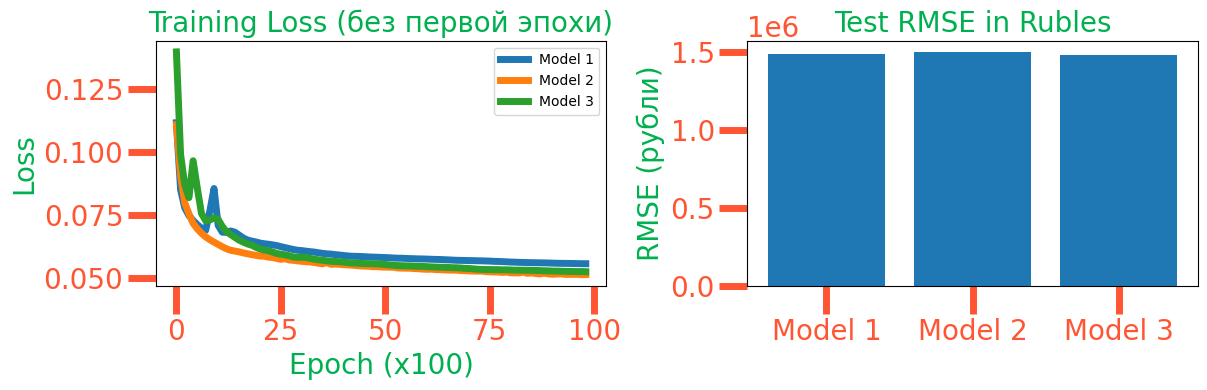

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
# Пропускаем первую точку (эпоху 0), чтобы график не был очень крутым
plt.plot(losses1[1:], label='Model 1')
plt.plot(losses2[1:], label='Model 2')
plt.plot(losses3[1:], label='Model 3')
plt.xlabel('Epoch (x100)')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss (без первой эпохи)')

plt.subplot(1, 2, 2)
models = ['Model 1', 'Model 2', 'Model 3']
rmse_rub_scores = [evaluate_model(m, X_test_tensor, y_test_tensor)[3] for m in [model1, model2, model3]]
plt.bar(models, rmse_rub_scores)
plt.ylabel('RMSE (рубли)')
plt.title('Test RMSE in Rubles')

plt.tight_layout()
plt.show()

**Вывод** :

функцию активации выбрал ReLu, так как ее проще реализовать) Функцию потерь выбрал мсе по классике для задачи регрессии за ее сильный штраф за большие пенальти. Все модели показали схожие результаты с ошибкой около 1.5 млн рублей, но уступили XGBoost из первой лабораторной, что наверное ожидаемо для простых нейросетей.